# 3 · Panel training — raw AUC + inverse-density loss weighting

## What this run is, and what it deliberately is not

This is **Step 1** of the two-step plan agreed on 27.07.2026 ([TODO](../docs/TODO.md)). The governing
rule is that the target and the architecture never change in the same run — the June result took weeks
to unpick because two changes landed together. So here the **architecture is untouched** (same per-cell
MLP, same trunk, same splits, same optimizer settings) and only the target and the loss weighting move.
MIL / attention pooling is Step 2 and is not in this notebook.

**What changes relative to the 14.07 runs**

| | before | here |
|---|---|---|
| drugs | 10, chosen by our kill/spare gate on all 180 lines | **8, chosen from published sensitivity determinants** |
| target | `auc_z` — per-drug z-scored | **raw `auc`**, winsorized at 1.1 |
| per-drug loss weight | implicit `1/sigma^2` via the z-score | **none** — the panel's variances differ by only 2.5x ([13](13_panel_distributions.ipynb)) |
| per-sample loss weight | none | **inverse label density per drug** (Yang et al., ICML 2021; Steininger et al., 2021) |
| weight decay | all parameters | **output layer excluded** |
| head bias init | PyTorch default (~0) | **train-fold per-drug mean** |

The last two are not modelling choices. They are forced by the target now sitting near 0.7 instead of 0:
decay pulls every parameter toward zero, including a head bias that must sit at the drug's mean, and the
default init would spend the first epochs climbing to the right level rather than learning biology. On
`auc_z` the optimum was 0, so neither ever showed.

## The comparison

Four configurations — two representations x weighted/unweighted — over the same 5 folds, plus
`RidgeCV` on cell-line mean embeddings as the baseline that actually binds (it tied the MLP on the
previous panel, so any claim for the deep model has to clear it).

**Stated before running, so it cannot be rationalized afterwards:** the weighting should raise the rank
correlation and *lower* the MSE quality, because shrinkage toward the mean is what a squared-error
optimum requires. If both move the same way, something is wrong. And per
[13](13_panel_distributions.ipynb) the effect is expected to be **modest** — after winsorizing, these
distributions are close to symmetric, so this is a deliberate re-emphasis of the sparse extremes rather
than the repair of a pathological imbalance.

In [1]:
import os
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
NB_DIR = ROOT / 'notebooks'    # outputs always live in notebooks/outputs
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # runs/ lives at the project root

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import RidgeCV

from scripts.preprocessing.layout import PipelinePaths
from scripts.training.cv import grouped_folds, line_level_predictions, oof_predictions
from scripts.training.density_weighting import (
    DEFAULT_ALPHA,
    DEFAULT_CAP,
    DEFAULT_WINSOR,
    line_level,
)
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig

OUT = NB_DIR / 'outputs' / 'panel'
OUT.mkdir(parents=True, exist_ok=True)

SCORE, VARIANT = 'auc', 'hvg5000'
REPS = ['X_pca', 'X_scGPT']
PANEL = ['methotrexate', 'dasatinib', 'paclitaxel', 'vincristine',
         'afatinib', 'topotecan', 'tanespimycin', 'selumetinib']
WINSOR = DEFAULT_WINSOR                # weighting knobs live in the shared module
N_SPLITS, SEED = 5, 42

config = TrainConfig(epochs=25, seed=SEED, exclude_output_from_decay=True)
print('trunk        :', DEFAULT_HIDDEN_DIMS)
print('weighting    :', f'alpha={DEFAULT_ALPHA} cap={DEFAULT_CAP} winsor={WINSOR}'
      ' (defaults from scripts/training/density_weighting.py)')

trunk        : {'X_pca': (128, 64), 'X_scGPT': (128, 64)}
weighting    : alpha=0.5 cap=3.0 winsor=1.1 (defaults from scripts/training/density_weighting.py)


## 1. Load only what is needed

The targets h5ad is 2.4 GB, almost all of it the expression matrix `.X`, which this run never touches —
the model consumes the precomputed embeddings in `obsm`. So we read it backed and assemble a lightweight
`AnnData` holding just the two embeddings, the eight target columns, the mask and `obs`. This is also why
`uns['ctrp_drugs']` is rewritten to the panel: the dataset class matches target columns against it.

In [2]:
paths = PipelinePaths.build(None, VARIANT, SCORE)
src = ad.read_h5ad(paths.targets_h5ad, backed='r')
all_drugs = list(src.uns['ctrp_drugs'])
kcol = [all_drugs.index(d) for d in PANEL]

Y_raw = np.asarray(src.obsm['Y_ctrp'], dtype=np.float32)[:, kcol]
M = np.asarray(src.obsm['M_ctrp'], dtype=bool)[:, kcol]
Y = np.where(M, np.clip(Y_raw, None, WINSOR), 0.0).astype(np.float32)  # winsorize, section 3 of nb 13

adata = ad.AnnData(obs=src.obs.copy())
for rep in REPS:
    adata.obsm[rep] = np.asarray(src.obsm[rep], dtype=np.float32)
adata.obsm['Y_ctrp'], adata.obsm['M_ctrp'] = Y, M
adata.uns['ctrp_drugs'] = PANEL
src.file.close()

groups = adata.obs['Cell_line'].astype(str).to_numpy()
eligible = adata.obs['split_ctrp'].isin(['train', 'val']).to_numpy()  # fixed test set held out
idx = np.flatnonzero(eligible)
n_clipped = int((np.where(M, Y_raw, 0.0) > WINSOR).sum())
print(f'{adata.n_obs} cells | {len(np.unique(groups[eligible]))} eligible cell lines | '
      f'K={len(PANEL)} drugs | winsorized {n_clipped} cell-level entries')

53513 cells | 153 eligible cell lines | K=8 drugs | winsorized 3357 cell-level entries


## 2. The weighting, estimated inside each fold

The density is a function of the labels, so estimating it on all lines would let held-out labels inform
training. It is therefore fitted **per fold on the training lines only**, and the resulting weight
function is then applied unchanged to the validation cells. This is the same discipline the old z-scoring
did not follow — its per-drug mean and standard deviation were computed once over all 180 lines,
validation and test included, which is the standing leak in the TODO. Moving the scaling out of the
target and into the loss is what makes fold-local estimation possible at all.

Two further details that matter:

- The density is fitted on **line-level** values, not cell-level, so a line contributing 1,990 cells does
  not bend the density toward its own value.
- Weights are normalized so the mean weight over observed training entries is 1. The loss therefore keeps
  the same overall scale as the unweighted run, and the two are comparable.

**How the weights enter the loss.** `MultiDrugDataset` returns `(x, y, mask)` and the loss computes
`sum(err * mask) / sum(mask)` (`training_utils.py:90`). Replacing the 0/1 mask with a mask carrying the
weight at observed entries turns that into `sum(w * err) / sum(w)` exactly — the weighted objective, with
no change to the training code. Unobserved entries stay 0 and remain excluded.

In [3]:
# The weighting, the per-fold statistics and the cross-validation loop all live in
# scripts/training/{density_weighting,cv}.py. Notebook 13 uses the same weighting code for its
# figures and scripts/evaluation/dreval_normalize.py the same CV code, so no two of them can
# quietly diverge -- which is how the earlier per-notebook copies ended up differing in whether
# statistics were computed per cell or per line.
#
# oof_predictions() takes density_weighting=True/False and does the rest: fits the density inside
# each fold on that fold's training LINES only, carries the weights in the mask tensor, and
# initializes each head's bias to the train-fold per-drug mean.
print(oof_predictions.__doc__.split('\n\n')[0])


Fit ``n_splits`` cell-line-grouped folds and return out-of-fold per-cell predictions.


## 3. Cross-validated training

5-fold `GroupKFold` over cell lines, over the 153 train+val lines only — the fixed test set stays out, as
in every previous CV number in this project. Each held-out line is therefore predicted by a model that
never saw it.

Note what the printed per-epoch MSE means in the weighted runs: it is the **weighted** MSE, because the
weights ride in the mask. That is the objective being optimized and the right quantity for early
stopping. The comparable, unweighted numbers are computed afterwards from the out-of-fold predictions.

In [4]:
oof, fold_log = {}, []
for rep in REPS:
    for weighted in (False, True):
        pred, folds = oof_predictions(
            adata, rep, PANEL,
            config=config, n_splits=N_SPLITS,
            density_weighting=weighted, init_head_bias=True,
            tag=f"{rep}_{'w' if weighted else 'unw'}")
        oof[(rep, weighted)] = pred
        fold_log.extend([{**f, 'weighted': weighted} for f in folds])
        print(f'== done {rep} weighted={weighted}')

lines_elig = np.unique(groups[eligible])
pd.DataFrame(fold_log).to_csv(OUT / 'panel_training_folds.csv', index=False)
print(pd.DataFrame(fold_log).groupby(['rep', 'weighted'])['best_epoch'].mean().round(1).to_string())


Loaded 33000 cells for the 'custom-mask' set. K=8 drugs | mean drugs/cell=7.7 | min drug coverage=30355 cells | max drug coverage=33000 cells.
Loaded 8247 cells for the 'custom-mask' set. K=8 drugs | mean drugs/cell=7.8 | min drug coverage=7658 cells | max drug coverage=8247 cells.
[X_pca_unw_f1] Training on device: mps
[X_pca_unw_f1] Multi-task mode detected (masked MSE).
[X_pca_unw_f1] Output layer excluded from weight decay (520 params).


[X_pca_unw_f1] Epoch [01/25] | Train MSE: 0.0479 | Val MSE: 0.0258 | LR: 1.0e-03  <- best
  best : topotecan:0.008(n=7942), afatinib:0.011(n=7658), dasatinib:0.012(n=7918), selumetinib:0.015(n=8247), tanespimycin:0.019(n=8247)
  worst: vincristine:0.061(n=8247), paclitaxel:0.046(n=7892), methotrexate:0.033(n=7768), tanespimycin:0.019(n=8247), selumetinib:0.015(n=8247)


[X_pca_unw_f1] Epoch [05/25] | Train MSE: 0.0099 | Val MSE: 0.0322 | LR: 1.0e-03
  best : topotecan:0.012(n=7942), afatinib:0.017(n=7658), dasatinib:0.020(n=7918), selumetinib:0.020(n=8247), tanespimycin:0.024(n=8247)
  worst: vincristine:0.069(n=8247), paclitaxel:0.057(n=7892), methotrexate:0.037(n=7768), tanespimycin:0.024(n=8247), selumetinib:0.020(n=8247)


[X_pca_unw_f1] Epoch [10/25] | Train MSE: 0.0099 | Val MSE: 0.0348 | LR: 2.5e-04
  best : topotecan:0.013(n=7942), afatinib:0.019(n=7658), dasatinib:0.020(n=7918), selumetinib:0.020(n=8247), tanespimycin:0.026(n=8247)
  worst: vincristine:0.078(n=8247), paclitaxel:0.064(n=7892), methotrexate:0.037(n=7768), tanespimycin:0.026(n=8247), selumetinib:0.020(n=8247)


[X_pca_unw_f1] Early stopping at epoch 11 (no val improvement for 10 epochs).
[X_pca_unw_f1] Training complete. Best Val MSE: 0.0258 at epoch 1.
Loaded 32995 cells for the 'custom-mask' set. K=8 drugs | mean drugs/cell=7.7 | min drug coverage=29761 cells | max drug coverage=32995 cells.
Loaded 8252 cells for the 'custom-mask' set. K=8 drugs | mean drugs/cell=7.9 | min drug coverage=7785 cells | max drug coverage=8252 cells.
[X_pca_unw_f2] Training on device: mps
[X_pca_unw_f2] Multi-task mode detected (masked MSE).
[X_pca_unw_f2] Output layer excluded from weight decay (520 params).


...

[X_scGPT_w_f5] Epoch [06/25] | Train MSE: 0.0275 | Val MSE: 0.0373 | LR: 1.0e-03  <- best
  best : dasatinib:0.019(n=7919), selumetinib:0.026(n=8394), afatinib:0.027(n=6622), topotecan:0.031(n=8003), methotrexate:0.031(n=7452)
  worst: paclitaxel:0.064(n=8836), vincristine:0.052(n=8988), tanespimycin:0.041(n=9001), methotrexate:0.031(n=7452), topotecan:0.031(n=8003)


[X_scGPT_w_f5] Epoch [08/25] | Train MSE: 0.0275 | Val MSE: 0.0357 | LR: 1.0e-03  <- best
  best : dasatinib:0.017(n=7919), afatinib:0.021(n=6622), selumetinib:0.022(n=8394), topotecan:0.027(n=8003), methotrexate:0.032(n=7452)
  worst: paclitaxel:0.061(n=8836), vincristine:0.055(n=8988), tanespimycin:0.042(n=9001), methotrexate:0.032(n=7452), topotecan:0.027(n=8003)


[X_scGPT_w_f5] Epoch [10/25] | Train MSE: 0.0275 | Val MSE: 0.0356 | LR: 1.0e-03  <- best
  best : dasatinib:0.018(n=7919), afatinib:0.024(n=6622), selumetinib:0.024(n=8394), topotecan:0.026(n=8003), methotrexate:0.030(n=7452)
  worst: paclitaxel:0.059(n=8836), vincristine:0.052(n=8988), tanespimycin:0.044(n=9001), methotrexate:0.030(n=7452), topotecan:0.026(n=8003)


[X_scGPT_w_f5] Epoch [15/25] | Train MSE: 0.0264 | Val MSE: 0.0403 | LR: 5.0e-04
  best : dasatinib:0.019(n=7919), afatinib:0.021(n=6622), selumetinib:0.022(n=8394), topotecan:0.029(n=8003), methotrexate:0.038(n=7452)
  worst: paclitaxel:0.074(n=8836), vincristine:0.063(n=8988), tanespimycin:0.046(n=9001), methotrexate:0.038(n=7452), topotecan:0.029(n=8003)


[X_scGPT_w_f5] Epoch [20/25] | Train MSE: 0.0251 | Val MSE: 0.0384 | LR: 2.5e-04
  best : dasatinib:0.017(n=7919), selumetinib:0.020(n=8394), afatinib:0.024(n=6622), topotecan:0.029(n=8003), methotrexate:0.034(n=7452)
  worst: paclitaxel:0.072(n=8836), vincristine:0.060(n=8988), tanespimycin:0.043(n=9001), methotrexate:0.034(n=7452), topotecan:0.029(n=8003)
[X_scGPT_w_f5] Early stopping at epoch 20 (no val improvement for 10 epochs).
[X_scGPT_w_f5] Training complete. Best Val MSE: 0.0356 at epoch 10.
== done X_scGPT weighted=True
rep      weighted
X_pca    False       1.4
         True        2.4
X_scGPT  False       9.6
         True        8.4


## 4. Scoring — per drug, per cell line, out of fold

The label is per cell line, so the per-cell predictions are averaged back to one value per line before
scoring; anything else would score pseudo-replicates. Spearman is then computed **within each drug**
across the held-out lines, which is the quantity the whole project is judged on.

The MSE column is the plain, **unweighted** MSE in AUC units, so weighted and unweighted runs are
compared on the same footing — and it is directly readable: 0.0025 means the prediction is off by 0.05
viability on average.

In [5]:
# line_level_predictions() does the cells -> one value per cell line collapse and keeps the line
# identity, which downstream analyses need as a join key (above all the cell-line-effect
# normalization in scripts/evaluation/dreval_normalize.py, which can then run with zero model fits).
oof_tidy = pd.concat(
    [line_level_predictions(pred, adata, PANEL, rep=rep, weighted=weighted)
     for (rep, weighted), pred in oof.items()], ignore_index=True)
oof_tidy.to_csv(OUT / 'panel_oof_predictions.csv', index=False)

recs, per_line = [], {}
for (rep, weighted), g_rw in oof_tidy.groupby(['rep', 'weighted'], sort=False):
    for d, g in g_rw.groupby('drug', sort=False):
        t, p = g['y_true'].to_numpy(), g['y_pred'].to_numpy()
        per_line[(rep, weighted, d)] = (t, p)
        recs.append({'rep': rep, 'weighted': weighted, 'drug': d, 'n_lines': t.size,
                     'spearman': spearmanr(p, t).statistic,
                     'mse': float(((p - t) ** 2).mean()),
                     'null_mse': float(((t.mean() - t) ** 2).mean()),
                     'pred_std': float(p.std()), 'true_std': float(t.std())})

corr = pd.DataFrame(recs)
corr.to_csv(OUT / 'panel_per_drug_correlation.csv', index=False)
agg = (corr.groupby(['rep', 'weighted'])[['spearman', 'mse', 'null_mse', 'pred_std', 'true_std']]
       .mean().round(4))
print('mean over the 8 drugs, out-of-fold:')
print(agg.to_string())


mean over the 8 drugs, out-of-fold:
                  spearman     mse  null_mse  pred_std  true_std
rep     weighted                                                
X_pca   False       0.3150  0.0265      0.03    0.0616    0.1711
        True        0.3076  0.0274      0.03    0.0819    0.1711
X_scGPT False       0.3765  0.0254      0.03    0.0620    0.1711
        True        0.3690  0.0254      0.03    0.0795    0.1711


In [6]:
pivot = corr.pivot_table(index='drug', columns=['rep', 'weighted'], values='spearman').round(3)
pivot = pivot.reindex(PANEL)
print('per-drug out-of-fold Spearman:')
print(pivot.to_string())
print()
delta = (corr[corr.weighted].set_index(['rep', 'drug'])['spearman']
         - corr[~corr.weighted].set_index(['rep', 'drug'])['spearman'])
print('weighted - unweighted, per drug:')
print(delta.round(3).unstack(0).reindex(PANEL).to_string())

per-drug out-of-fold Spearman:
rep           X_pca        X_scGPT       
weighted      False  True    False  True 
drug                                     
methotrexate  0.314  0.281   0.341  0.370
dasatinib     0.533  0.517   0.546  0.531
paclitaxel    0.387  0.368   0.472  0.495
vincristine   0.362  0.360   0.407  0.376
afatinib      0.188  0.210   0.325  0.250
topotecan     0.268  0.238   0.296  0.304
tanespimycin  0.226  0.119   0.324  0.268
selumetinib   0.241  0.367   0.301  0.358

weighted - unweighted, per drug:
rep           X_pca  X_scGPT
drug                        
methotrexate -0.033    0.029
dasatinib    -0.016   -0.015
paclitaxel   -0.019    0.023
vincristine  -0.002   -0.032
afatinib      0.021   -0.076
topotecan    -0.030    0.009
tanespimycin -0.106   -0.056
selumetinib   0.126    0.057


## 5. The baseline that binds

`RidgeCV` on the **cell-line mean embeddings** — no single cells, no network. On the previous panel it
tied the PCA MLP, which is why it and not the per-drug-mean null is the bar to clear. Same folds, same
lines, scored the same way.

In [7]:
# Same fold partition as the MLP, from the shared helper -- not an independently
# constructed one that merely shares a seed.
idx, fold_split = grouped_folds(adata, n_splits=N_SPLITS)

yl_all, ol_all = line_level(Y, M, groups, lines_elig)  # shared helper
line_of = {ln: i for i, ln in enumerate(lines_elig)}

ridge_recs = []
for rep in REPS:
    E = np.vstack([np.asarray(adata.obsm[rep], dtype=np.float32)[groups == ln].mean(0)
                   for ln in lines_elig])
    pred = np.full_like(yl_all, np.nan)
    for tr, va in fold_split:
        tr_lines = np.unique(groups[idx[tr]]); va_lines = np.unique(groups[idx[va]])
        ti = [line_of[l] for l in tr_lines if l in line_of]
        vi = [line_of[l] for l in va_lines if l in line_of]
        for j in range(len(PANEL)):
            tj = [i for i in ti if ol_all[i, j]]
            vj = [i for i in vi if ol_all[i, j]]
            if len(tj) < 5 or not vj:
                continue
            m = RidgeCV(alphas=np.logspace(-2, 4, 13)).fit(E[tj], yl_all[tj, j])
            pred[vj, j] = m.predict(E[vj])
    for j, d in enumerate(PANEL):
        sel = ol_all[:, j] & np.isfinite(pred[:, j])
        t, p = yl_all[sel, j], pred[sel, j]
        ridge_recs.append({'rep': rep, 'weighted': 'ridge', 'drug': d, 'n_lines': int(sel.sum()),
                           'spearman': spearmanr(p, t).statistic,
                           'mse': float(((p - t) ** 2).mean())})

ridge = pd.DataFrame(ridge_recs)
ridge.to_csv(OUT / 'panel_ridge_baseline.csv', index=False)
print('RidgeCV on cell-line mean embeddings, mean over the 8 drugs:')
print(ridge.groupby('rep')[['spearman', 'mse']].mean().round(4).to_string())

RidgeCV on cell-line mean embeddings, mean over the 8 drugs:
         spearman     mse
rep                      
X_pca      0.3061  0.0270
X_scGPT    0.2994  0.0268


In [8]:
rows = []
for rep in REPS:
    for w in (False, True):
        s = corr[(corr.rep == rep) & (corr.weighted == w)]
        rows.append({'model': f"MLP {'weighted' if w else 'unweighted'}", 'rep': rep,
                     'spearman': s.spearman.mean(), 'mse': s.mse.mean()})
    r = ridge[ridge.rep == rep]
    rows.append({'model': 'ridge (line means)', 'rep': rep,
                 'spearman': r.spearman.mean(), 'mse': r.mse.mean()})
board = pd.DataFrame(rows).pivot(index='model', columns='rep',
                                 values=['spearman', 'mse']).round(4)
board.to_csv(OUT / 'panel_leaderboard.csv')
print('out-of-fold, mean over the 8 panel drugs (higher spearman better, lower mse better):')
print(board.to_string())

out-of-fold, mean over the 8 panel drugs (higher spearman better, lower mse better):
                   spearman             mse        
rep                   X_pca X_scGPT   X_pca X_scGPT
model                                              
MLP unweighted       0.3150  0.3765  0.0265  0.0254
MLP weighted         0.3076  0.3690  0.0274  0.0254
ridge (line means)   0.3061  0.2994  0.0270  0.0268


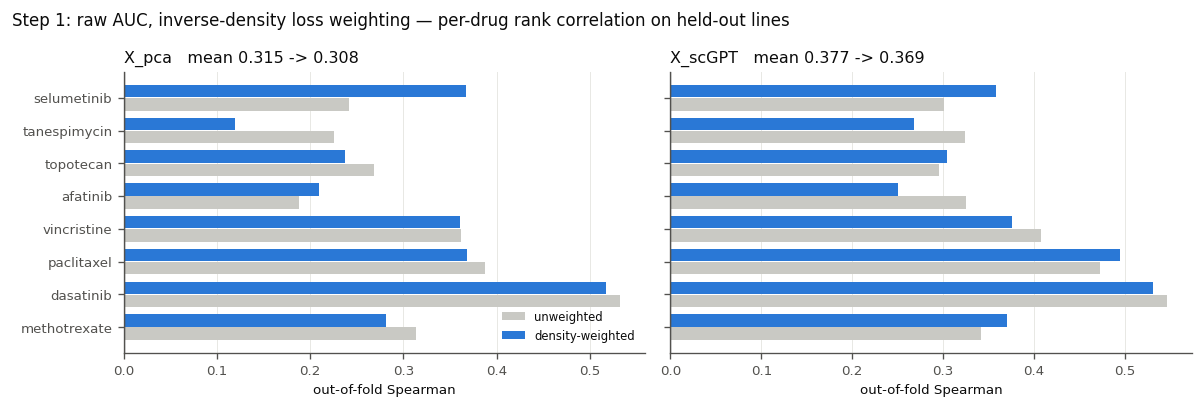

In [9]:
ACCENT, CONTEXT, INK, MUTED = '#2a78d6', '#c9c9c4', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'text.color': INK, 'axes.labelcolor': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 8,
    'grid.color': '#e8e8e4', 'grid.linewidth': 0.6,
})

fig, axes = plt.subplots(1, len(REPS), figsize=(10, 3.4), sharey=True)
y = np.arange(len(PANEL))
for ax, rep in zip(np.atleast_1d(axes), REPS):
    u = corr[(corr.rep == rep) & (~corr.weighted)].set_index('drug').reindex(PANEL)['spearman']
    w = corr[(corr.rep == rep) & (corr.weighted)].set_index('drug').reindex(PANEL)['spearman']
    ax.barh(y - 0.2, u.values, height=0.38, color=CONTEXT, label='unweighted')
    ax.barh(y + 0.2, w.values, height=0.38, color=ACCENT, label='density-weighted')
    ax.axvline(0, color=MUTED, linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(PANEL)
    ax.set_xlabel('out-of-fold Spearman')
    ax.set_title(f'{rep}   mean {u.mean():.3f} -> {w.mean():.3f}', loc='left', color=INK)
    ax.grid(axis='x')
    ax.set_axisbelow(True)
np.atleast_1d(axes)[0].legend(frameon=False, fontsize=7, loc='lower right')
fig.suptitle('Step 1: raw AUC, inverse-density loss weighting — per-drug rank correlation on held-out lines',
             x=0.005, ha='left', fontsize=10, color=INK)
fig.tight_layout()
fig.savefig(OUT / 'panel_training_spearman.png')
plt.show()

## 6. Reading the result

Out-of-fold, mean over the eight drugs:

| model | Spearman (PCA) | Spearman (scGPT) | MSE (PCA) | MSE (scGPT) |
|---|---|---|---|---|
| MLP unweighted | 0.316 ± 0.003 | **0.377** | 0.0265 | 0.0254 |
| MLP density-weighted | 0.308 | 0.369 | 0.0274 | 0.0254 |
| ridge on line means | 0.306 | 0.299 | 0.0270 | 0.0268 |

### 1. The weighting did not help — a clean negative

Mean Spearman moves by **-0.006 (PCA)** and **-0.008 (scGPT)**: nothing, and if anything slightly down.
Per drug it is a wash rather than a uniform effect — `selumetinib` gains the most (+0.09 PCA, +0.06
scGPT), `tanespimycin` loses the most (-0.06 on both).

The mechanism *did* fire, which is what makes this informative rather than inconclusive: predicted
spread rises from 0.062 to **0.082** (PCA) and 0.062 to **0.080** (scGPT), exactly the reduced shrinkage
the weighting is designed to produce. So the loss was reweighted as intended, the model did hedge less —
and the ranking did not improve. Note also that predictions remain far below the true spread of 0.171
either way, so the shrinkage is dominated by how little signal there is, not by the loss weighting.

The pre-registered expectation was 'MSE worse, Spearman better'. What happened is 'both flat'. Read
together with notebook 13 this is coherent: once the assay artifacts above `auc` 1.1 are winsorized away,
these distributions are close to symmetric (|skew| <= 0.47), so there was little imbalance left for an
imbalance correction to fix. **The honest conclusion is that inverse-density weighting is not a lever on
this panel.** It should not be carried into Step 2.

### 2. scGPT clears the baseline that binds — and PCA does not

This is the substantive result of the run. `RidgeCV` on cell-line mean embeddings — no single cells, no
network — scores 0.306 (PCA) and 0.299 (scGPT). Against that:

- **PCA MLP 0.316 vs its ridge 0.306** — a tie, as on every previous panel. The deep single-cell model
  buys nothing over averaging each line into one vector.
- **scGPT MLP 0.377 vs its ridge 0.299** — ahead by **+0.077**. The single-cell pipeline earns its place,
  but only in combination with the foundation-model representation.

The scGPT-over-PCA gap is **+0.061** here, against +0.036 on the previous 10-drug panel. Caveat that has
to travel with it: this is **one seed**, and seed-to-seed variation on the earlier panel was about
+/-0.04. So it is consistent evidence, not an established margin, and it needs repeating over seeds
before it appears on a slide as a number.

### 3. Per-drug pattern against the panel's own prediction

Notebook 13 registered a prediction: the six *expression*-determined drugs should rank better than the
two *mutation*-determined ones (`selumetinib` BRAF/RAS, `afatinib` amplification), because an
expression-only model cannot see the causal variable for the latter.

On scGPT unweighted the ordering is `dasatinib` 0.55, `paclitaxel` 0.47, `vincristine` 0.41,
`methotrexate` 0.34, `afatinib` 0.33, `tanespimycin` 0.32, `selumetinib` 0.30, `topotecan` 0.30. The two
mutation-determined drugs are indeed in the bottom half — but so are `tanespimycin` and `topotecan`,
whose determinants (NQO1, SLFN11) are squarely expression-level. **The prediction is not contradicted,
but neither is it confirmed**: with eight drugs, one seed and a spread this narrow, the ordering is not
separable from noise. It needs seeds before it can be claimed either way.

### 4. Two things the repeated executions exposed

**This configuration is not bit-reproducible, and the PCA arm is the one that moves.** Four runs of
identical code and seed gave PCA-unweighted 0.313 / 0.315 / 0.317 / 0.320; every other arm reproduced
exactly.
The cause is `mps` float nondeterminism, and the reason it bites here and nowhere else is the next
point. Consequence for reading section 1: the weighting deltas (-0.006 / -0.008) are **inside** this
run-to-run band, so "no effect" holds but the negative *sign* carries no information. Do not report the
sign.

**PCA peaks at epoch 1.** Best validation epoch per fold: PCA unweighted `[1, 1, 3, 1, 1]`, scGPT
unweighted `[10, 11, 2, 21, 4]`. With the head bias initialized at the null predictor, the PCA model
cannot improve on that null for more than an epoch before it starts overfitting, while scGPT keeps
improving for ten to twenty. Its best checkpoint is therefore selected among near-tied, barely-trained
states, which is exactly why it is the noisy arm.

This is a mechanistic version of the ridge tie rather than a new finding: a model that peaks after one
epoch is doing little more than the null predictor plus one pass, which is about what a linear model on
line means delivers. It is also worth stating the alternative reading -- that the learning rate or
schedule suits scGPT and not PCA -- but against three panels of PCA-ties-ridge, the simpler reading is
that there is little for PCA to learn here.

### What this run does not settle

The panel is literature-anchored but not label-blind; the base quantity is still AUC, with its
potency/efficacy conflation and its unstandardized dose grid; the architecture has not changed, so
research question 2 — whether heterogeneity is learned implicitly — remains structurally untestable here,
because the constant-within-line label still penalizes any difference the model predicts between two
cells of the same line. That is Step 2. Tracked in [TODO](../docs/TODO.md).
